In [171]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"C:/Users/ibade/OneDrive/Bureau/Telecom/2A/MODS/Data analysis 1/Data/RawData.xlsx"


df = pd.read_excel(file_path)

print(df.columns)


Index(['Title', 'Title_1', 'ID', 'Rating', 'Release Year', 'Duration',
       'BoxOfficeMojo_Link', 'Worldwide Gross', 'Domestic Gross',
       'International Gross', 'Director', 'Cast and Crew'],
      dtype='object')


In [172]:


df_gross=df.dropna()


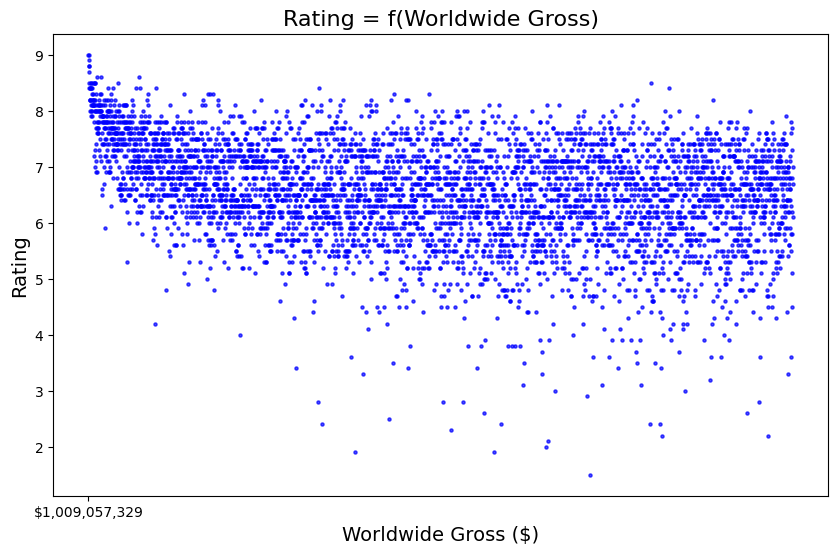

In [173]:
#Rating in function of worldwide gross


plt.figure(figsize=(10, 6))
plt.scatter(df_gross['Worldwide Gross'], df_gross['Rating'], color='blue', alpha=0.7, s=5)


plt.title('Rating = f(Worldwide Gross)', fontsize=16)
plt.xlabel('Worldwide Gross ($)', fontsize=14)
plt.ylabel('Rating', fontsize=14)


plt.xticks([0])


plt.show()


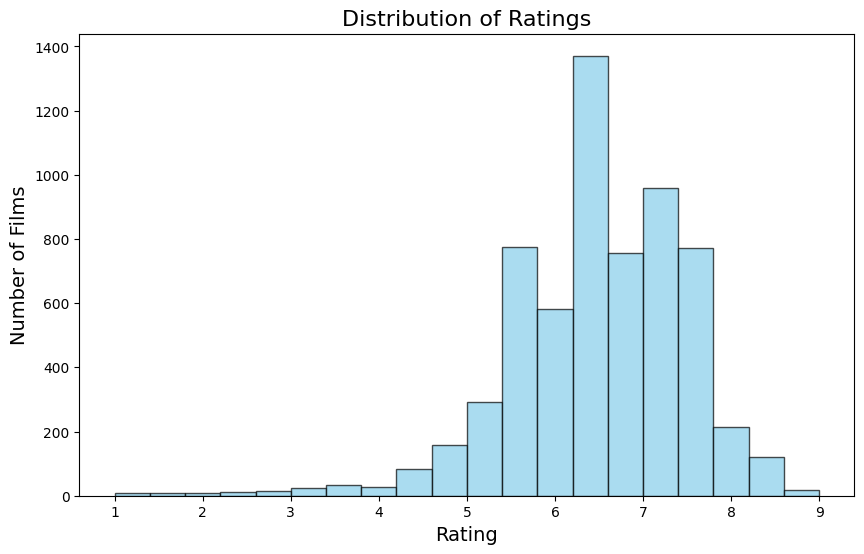

In [174]:
#Histogram of the rating distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Rating'].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Ratings', fontsize=16)
plt.xlabel('Rating', fontsize=14)
plt.ylabel('Number of Films', fontsize=14)


plt.show()

In [175]:
#Top 10 film directors by rating

df_clean = df.dropna(subset=['Director', 'Rating'])


directors_grouped = df_clean.groupby('Director')


directors_stats = directors_grouped['Rating'].agg(['mean', 'count']).reset_index()

top_directors = directors_stats[directors_stats['count'] > 5]


top_directors_sorted = top_directors.sort_values(by='mean', ascending=False)


top_10_directors = top_directors_sorted.head(10)


print(top_10_directors)



               Director      mean  count
530   Christopher Nolan  8.220000     10
2295  Quentin Tarantino  8.025000      8
2234      Peter Jackson  7.937500      8
731    Denis Villeneuve  7.775000      8
1848    Martin Scorsese  7.757143      7
1123   Hirokazu Koreeda  7.657143      7
245      Asghar Farhadi  7.657143      7
2501         S. Shankar  7.650000      6
348        Bong Joon Ho  7.633333      6
2111  Nuri Bilge Ceylan  7.628571      7


In [176]:
#Top 10 directors by revenues
df_clean = df.dropna(subset=['Director', 'Worldwide Gross'])


df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)


directors_grouped = df_clean.groupby('Director')


directors_stats = directors_grouped['Worldwide Gross'].agg(['sum', 'count']).reset_index()

top_directors = directors_stats[directors_stats['count'] > 5]


top_directors['average_revenue'] = top_directors['sum'] / top_directors['count']


top_directors_sorted = top_directors.sort_values(by='average_revenue', ascending=False)


top_10_directors = top_directors_sorted.head(10)


print(top_10_directors[['Director', 'average_revenue', 'count']])


               Director  average_revenue  count
189       Anthony Russo     1.142687e+09      6
2017      Peter Jackson     8.192092e+08      8
637         David Yates     8.046906e+08      8
1054        J.J. Abrams     7.766592e+08      6
2281          Sam Raimi     6.736542e+08      6
469   Christopher Nolan     6.179330e+08     10
1726        Michael Bay     5.405614e+08     10
364        Bryan Singer     5.328789e+08      6
1287        Jon Favreau     4.850627e+08      9
827    Francis Lawrence     4.649363e+08      8


C:\Users\ibade\AppData\Local\Temp\ipykernel_10328\922839424.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\ibade\AppData\Local\Temp\ipykernel_10328\922839424.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_directors['average_revenue'] = top_directors['sum'] / top_directors['count']


In [177]:
#Top 10 actors by rating
if 'Cast and Crew' in df.columns and 'Rating' in df.columns:
 
    df_clean = df.dropna(subset=['Cast and Crew', 'Rating']).copy()
    

    def extract_actors(cast_crew):

        actors = [actor.split(" (")[0].strip() for actor in cast_crew.split(",")]
        return actors
    

    df_clean['Actors'] = df_clean['Cast and Crew'].apply(extract_actors)
    

    actor_ratings = []
    for _, row in df_clean.iterrows():
        for actor in row['Actors']:
            actor_ratings.append({'Actor': actor, 'Rating': row['Rating']})
    

    actor_ratings_df = pd.DataFrame(actor_ratings)
    

    actor_counts = actor_ratings_df.groupby('Actor').size().rename('Number of Films')
    

    valid_actors = actor_counts[actor_counts >= 17].index
    

    filtered_actor_ratings = actor_ratings_df[actor_ratings_df['Actor'].isin(valid_actors)]
 
    actor_avg_rating = filtered_actor_ratings.groupby('Actor')['Rating'].mean().rename('Average Rating')

    actor_summary = pd.concat([actor_avg_rating, actor_counts], axis=1).dropna()
    

    actor_summary = actor_summary.sort_values(by='Average Rating', ascending=False)
    

    top_actors = actor_summary.head(10)
    

    print("Top 10 best actors (at least 5 films) by average rating:")
    print(top_actors)
else:
    print("The 'Cast and Crew' or 'Rating' columns do not exist in the DataFrame.")


Top 10 best actors (at least 5 films) by average rating:
                        Average Rating  Number of Films
Actor                                                  
Leonardo DiCaprio             7.747059               17
Robert Downey Jr.             7.248000               25
Ajay Devgn                    7.211765               17
Philip Seymour Hoffman        7.210526               19
Mads Mikkelsen                7.147059               17
Brad Pitt                     7.082143               28
Ryan Gosling                  7.054167               24
Emma Watson                   7.052941               17
Christian Bale                7.050000               30
Tom Cruise                    7.033333               21


In [178]:
#Top 10 actors by revenues
if 'Cast and Crew' in df.columns and 'Worldwide Gross' in df.columns:

    df_clean = df.dropna(subset=['Cast and Crew', 'Worldwide Gross']).copy()
    
   
    df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)
    

    def extract_actors(cast_crew):
      
        actors = [actor.split(" (")[0].strip() for actor in cast_crew.split(",")]
        return actors
    

    df_clean['Actors'] = df_clean['Cast and Crew'].apply(extract_actors)
    

    actor_gross = []
    for _, row in df_clean.iterrows():
        for actor in row['Actors']:
            actor_gross.append({'Actor': actor, 'Worldwide Gross': row['Worldwide Gross']})
    

    actor_gross_df = pd.DataFrame(actor_gross)
    

    actor_counts = actor_gross_df.groupby('Actor').size().rename('Number of Films')
    

    valid_actors = actor_counts[actor_counts >= 20].index
    

    filtered_actor_gross = actor_gross_df[actor_gross_df['Actor'].isin(valid_actors)]

    actor_avg_gross = filtered_actor_gross.groupby('Actor')['Worldwide Gross'].mean().rename('Average Worldwide Gross')
    

    actor_summary_gross = pd.concat([actor_avg_gross, actor_counts], axis=1).dropna()
    

    actor_summary_gross = actor_summary_gross.sort_values(by='Average Worldwide Gross', ascending=False)
    
   
    top_actors_gross = actor_summary_gross.head(10)
    

    print("Top 10 best actors (at least 5 films) by average worldwide gross:")
    print(top_actors_gross)
else:
    print("The 'Cast and Crew' or 'Worldwide Gross' columns do not exist in the DataFrame.")


Top 10 best actors (at least 5 films) by average worldwide gross:
                   Average Worldwide Gross  Number of Films
Actor                                                      
Robert Downey Jr.             6.169708e+08               25
Vin Diesel                    4.360692e+08               21
Chris Evans                   4.204963e+08               28
Tom Cruise                    4.119024e+08               21
Will Smith                    3.617283e+08               20
Dwayne Johnson                3.285372e+08               37
Mark Ruffalo                  3.172368e+08               29
Jack Black                    2.922555e+08               24
Johnny Depp                   2.838059e+08               33
Daniel Craig                  2.761690e+08               21


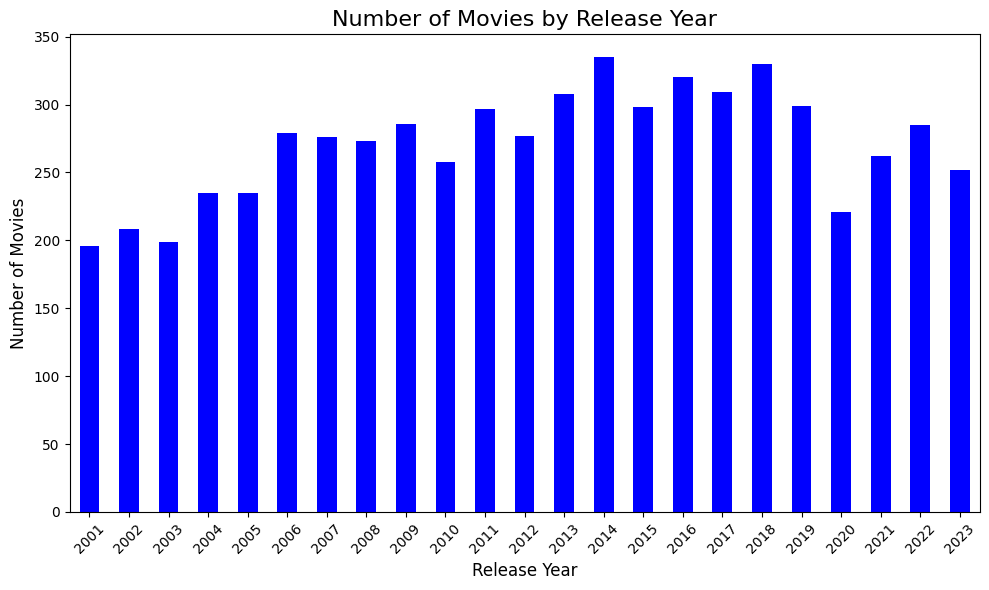

In [179]:
#Number of Movies by Release Year
if 'Title' in df.columns and 'Release Year' in df.columns:

    df_clean = df.dropna(subset=['Release Year']).copy()


    films_per_year = df_clean.groupby('Release Year').size()


    plt.figure(figsize=(10, 6))
    films_per_year.plot(kind='bar', color='blue')


    plt.title('Number of Movies by Release Year', fontsize=16)
    plt.xlabel('Release Year', fontsize=12)
    plt.ylabel('Number of Movies', fontsize=12)

 
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("The columns 'Title' or 'Release Year' do not exist in the DataFrame.")


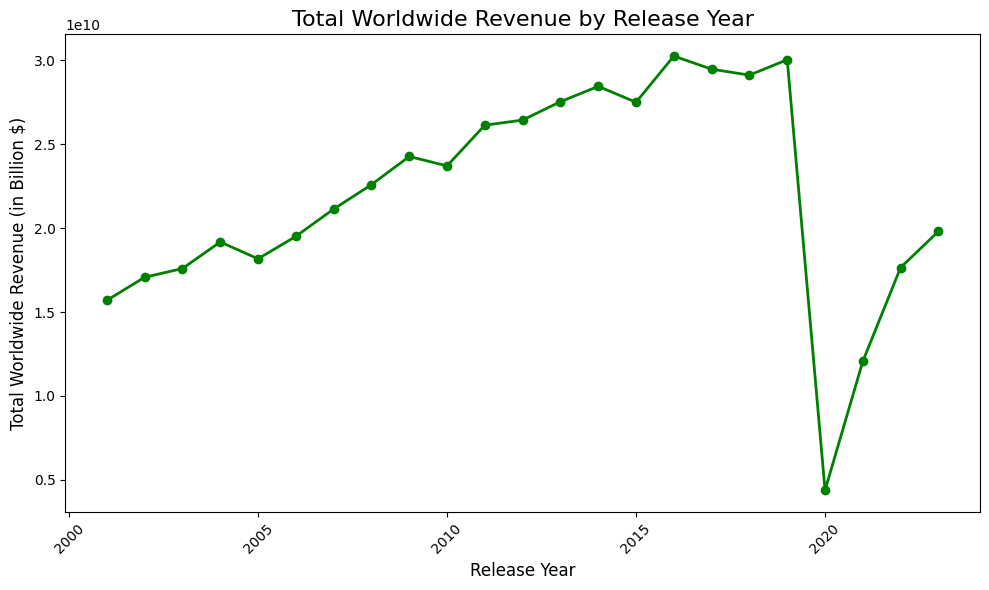

In [180]:
#Total Worldwide Revenue by Release Year
if 'Release Year' in df.columns and 'Worldwide Gross' in df.columns:

    df_clean = df.dropna(subset=['Release Year', 'Worldwide Gross']).copy()


    df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)


    revenue_per_year = df_clean.groupby('Release Year')['Worldwide Gross'].sum()


    plt.figure(figsize=(10, 6))
    revenue_per_year.plot(kind='line', color='green', marker='o', linestyle='-', linewidth=2, markersize=6)

  
    plt.title('Total Worldwide Revenue by Release Year', fontsize=16)
    plt.xlabel('Release Year', fontsize=12)
    plt.ylabel('Total Worldwide Revenue (in Billion $)', fontsize=12)


    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("The 'Release Year' or 'Worldwide Gross' columns do not exist in the DataFrame.")


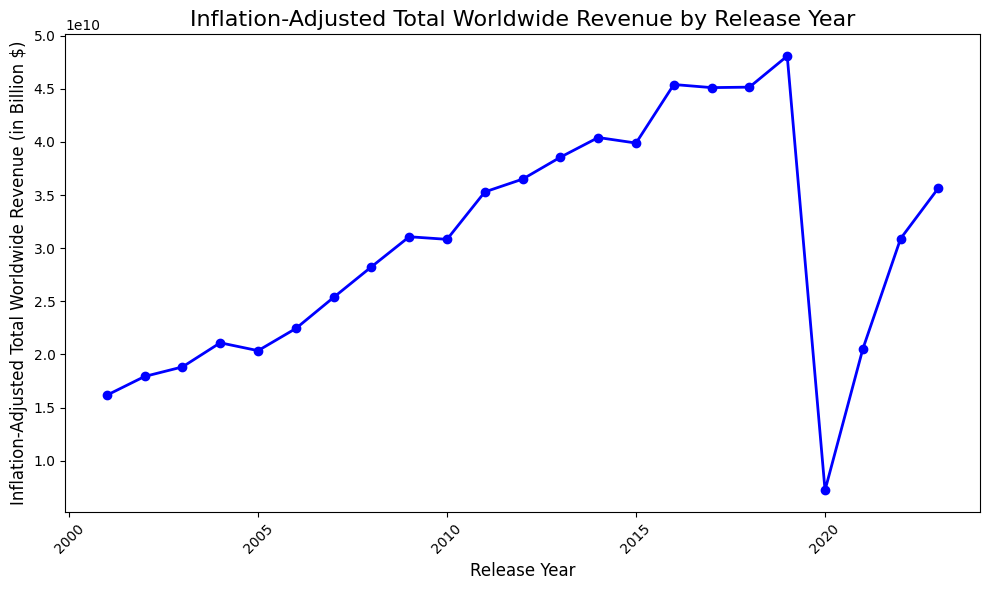

In [181]:
#'Inflation-Adjusted Total Worldwide Revenue by Release Year
inflation_index = {
    2000: 1.00,
    2001: 1.03,
    2002: 1.05,
    2003: 1.07,
    2004: 1.10,
    2005: 1.12,
    2006: 1.15,
    2007: 1.20,
    2008: 1.25,
    2009: 1.28,
    2010: 1.30,
    2011: 1.35,
    2012: 1.38,
    2013: 1.40,
    2014: 1.42,
    2015: 1.45,
    2016: 1.50,
    2017: 1.53,
    2018: 1.55,
    2019: 1.60,
    2020: 1.65,
    2021: 1.70,  
    2022: 1.75,  
    2023: 1.80   
}

if 'Release Year' in df.columns and 'Worldwide Gross' in df.columns:

    df_clean = df.dropna(subset=['Release Year', 'Worldwide Gross']).copy()

    df_clean['Worldwide Gross'] = df_clean['Worldwide Gross'].replace('[\$,]', '', regex=True).astype(float)


    df_clean['Inflation Index'] = df_clean['Release Year'].map(inflation_index)


    df_clean['Adjusted Worldwide Gross'] = df_clean['Worldwide Gross'] * df_clean['Inflation Index']


    revenue_per_year_adjusted = df_clean.groupby('Release Year')['Adjusted Worldwide Gross'].sum()

    plt.figure(figsize=(10, 6))
    revenue_per_year_adjusted.plot(kind='line', color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)


    plt.title('Inflation-Adjusted Total Worldwide Revenue by Release Year', fontsize=16)
    plt.xlabel('Release Year', fontsize=12)
    plt.ylabel('Inflation-Adjusted Total Worldwide Revenue (in Billion $)', fontsize=12)


    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("The 'Release Year' or 'Worldwide Gross' columns do not exist in the DataFrame.")
